# Compare two finite-temperature conductance simulations

This notebook loads the two `.npz` datasets, copies the main quantities into simple NumPy arrays, checks that the magnetic-field grids coincide, and plots

\[
\Delta G(B) = G_1(B)-G_0(B).
\]

The conductances stored in `G_2terminal` are in units of \(e^2/h\).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Input files
# ============================================================

file_0 = "0two_terminal_transport_results_finite_T.npz"
file_1 = "1two_terminal_transport_results_finite_T.npz"

data_0 = np.load(file_0, allow_pickle=True)
data_1 = np.load(file_1, allow_pickle=True)

print("Dataset 0 keys:")
print(data_0.files)

print("\nDataset 1 keys:")
print(data_1.files)

Dataset 0 keys:
['B', 'mu', 'indices', 'kBT_meV', 'temperature_K', 'temperature_mode', 'T_over_hbar_omega_c', 'window_kBT', 'n_energy_points', 'G_T0', 'G_2terminal', 'R_2terminal', 'G10', 'energy_grids_meV', 'G_energy_e2h', 'T_mu_stack', 'T_stack']

Dataset 1 keys:
['B', 'mu', 'indices', 'kBT_meV', 'temperature_K', 'temperature_mode', 'T_over_hbar_omega_c', 'window_kBT', 'n_energy_points', 'G_T0', 'G_2terminal', 'R_2terminal', 'G10', 'energy_grids_meV', 'G_energy_e2h', 'T_mu_stack', 'T_stack']


In [3]:
# ============================================================
# Store the relevant quantities in simple NumPy arrays
# ============================================================

# Dataset 0
B_0  = np.array(data_0["B"])
mu_0 = np.array(data_0["mu"])
G_0  = np.array(data_0["G_2terminal"])
R_0  = np.array(data_0["R_2terminal"])

# Dataset 1
B_1  = np.array(data_1["B"])
mu_1 = np.array(data_1["mu"])
G_1  = np.array(data_1["G_2terminal"])
R_1  = np.array(data_1["R_2terminal"])

print("Number of B points:")
print("dataset 0:", len(B_0))
print("dataset 1:", len(B_1))

Number of B points:
dataset 0: 300
dataset 1: 300


In [4]:
# ============================================================
# Check that the two simulations use the same B grid
# ============================================================

same_B_grid = np.allclose(B_0, B_1)

print("Same B grid:", same_B_grid)

if not same_B_grid:
    raise ValueError(
        "The two datasets have different B grids. "
        "Interpolation is required before subtracting the conductances."
    )

# Since the grids coincide, use a single B array from now on
B = B_0.copy()

Same B grid: True


In [5]:
from scipy.ndimage import gaussian_filter

G_0_smooth = gaussian_filter(G_0, sigma=1)
G_1_smooth = gaussian_filter(G_1, sigma=1)

# ============================================================
# Conductance difference
# ============================================================

# Difference: dataset 1 minus dataset 0
Delta_G = G_1_smooth - G_0_smooth + 1
rhoxxnu = (1-Delta_G)/Delta_G

In [6]:

# ============================================================
# Find centers of integer conductance plateaus
# ============================================================

G = np.asarray(G_0_smooth)
B = np.asarray(B_0)

# Tolerance for considering G "integer"
tol = 0.05

plateau_centers = []

# Integers covered by the conductance range
n_min = max(1, int(np.ceil(np.min(G))))
n_max = int(np.floor(np.max(G)))

for n in range(n_min, n_max + 1):

    # Points sufficiently close to integer n
    mask = np.abs(G - n) < tol
    indices = np.where(mask)[0]

    if len(indices) == 0:
        continue

    # Split into contiguous regions
    regions = np.split(
        indices,
        np.where(np.diff(indices) > 1)[0] + 1
    )

    # If there are multiple regions, keep the widest one
    region = max(regions, key=len)

    # Center of plateau in B
    B_left  = B[region[0]]
    B_right = B[region[-1]]
    B_center = 0.5 * (B_left + B_right)

    # Index closest to the plateau center
    idx_center = region[np.argmin(np.abs(B[region] - B_center))]

    plateau_centers.append((n, idx_center, B[idx_center]))


# Print results
print("Plateau   index       B")
print("--------------------------")
for n, idx, Bc in plateau_centers:
    print(f"{n:4d}     {idx:5d}     {Bc:.6f}")


# Convenient arrays
plateau_n   = np.array([p[0] for p in plateau_centers])
plateau_idx = np.array([p[1] for p in plateau_centers])
plateau_B   = np.array([p[2] for p in plateau_centers])

Plateau   index       B
--------------------------
   2       283     3.676768
   3       225     2.505051
   4       192     1.896790
   5       159     1.515808
   6       133     1.266385
   7       110     1.083023
   8        90     0.952026
   9        69     0.842962
  10        46     0.756987


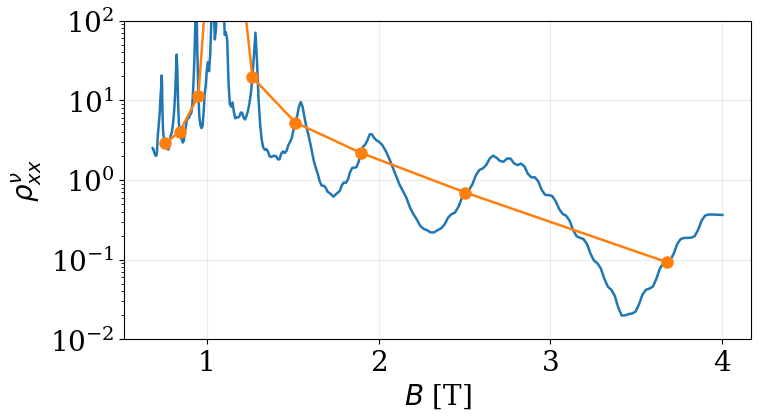

In [13]:
# ============================================================
# Plot Delta G(B)
# ============================================================

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(B, abs(rhoxxnu), ms=4, lw=1.8)
ax.plot(B[plateau_idx], abs(rhoxxnu[plateau_idx]), marker="o", ms=8, lw=1.8)


ax.axhline(0, color="0.5", ls="--", lw=1)

ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$\rho_{xx}^{\nu}$")

ax.grid(alpha=0.25)
ax.set_yscale("log")
fig.tight_layout()
ax.set_ylim(1e-2,1e2)
plt.savefig("rhoxxnuf.pdf")
plt.show()

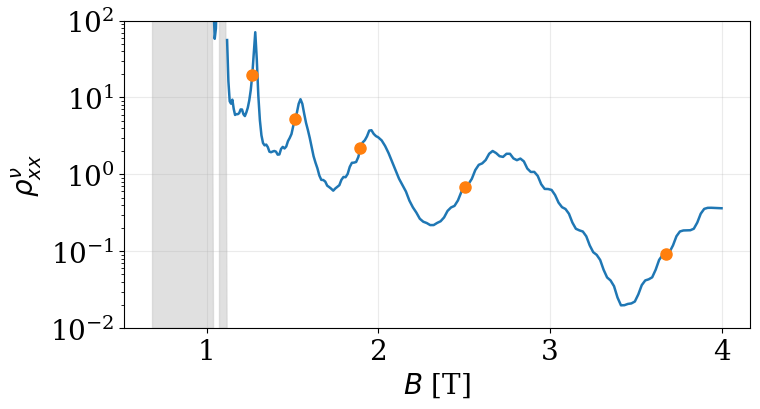

In [8]:
# ============================================================
# Plot rho_xx^nu(B)
# Show only rho_xx^nu > 0 and shade regions where rho_xx^nu <= 0
# ============================================================

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

fig, ax = plt.subplots(figsize=(8, 4.5))


# ------------------------------------------------------------
# Mask non-positive values
# ------------------------------------------------------------
rho_plot = np.where(rhoxxnu > 0, rhoxxnu, np.nan)

ax.plot(
    B,
    rho_plot,
    ms=4,
    lw=1.8
)


# ------------------------------------------------------------
# Plateau points: plot only if rho_xx^nu > 0
# ------------------------------------------------------------
valid_plateau = rhoxxnu[plateau_idx] > 0

ax.plot(
    B[plateau_idx][valid_plateau],
    rhoxxnu[plateau_idx][valid_plateau],
    marker="o",
    ls="none",
    ms=8
)


# ------------------------------------------------------------
# Shade B regions where rho_xx^nu <= 0
# ------------------------------------------------------------
negative_mask = rhoxxnu <= 0

ax.fill_between(
    B,
    1e-2,
    1e2,
    where=negative_mask,
    color="0.8",
    alpha=0.6,
    interpolate=True
)


# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------
ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$\rho_{xx}^{\nu}$")

ax.set_yscale("log")
ax.set_ylim(1e-2, 1e2)

ax.grid(alpha=0.25)

fig.tight_layout()

plt.savefig("rhoxxnuf_positive.pdf")
plt.show()

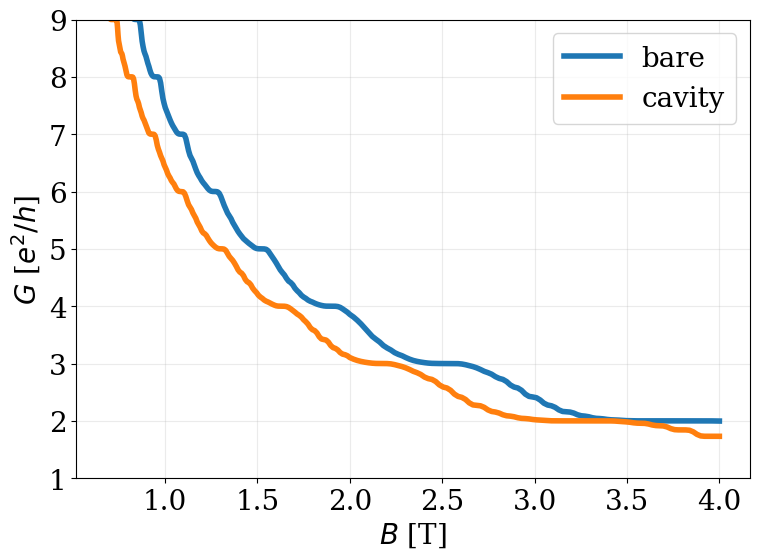

In [9]:
# Optional: plot the two original conductances for comparison

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(B_0, G_0_smooth, lw=4, label="bare")
ax.plot(B_1, G_1_smooth, lw=4, label="cavity")
#plt.plot(B_0,1.84e-3 * 2*np.pi*25.5**2 / B_0,label=r"$\propto 1/B$ reference",)

ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$G$ [$e^2/h$]")

ax.set_yticks(np.arange(0,12,1) )
ax.set_ylim(1,9)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.savefig('G_comparison.pdf')
plt.show()

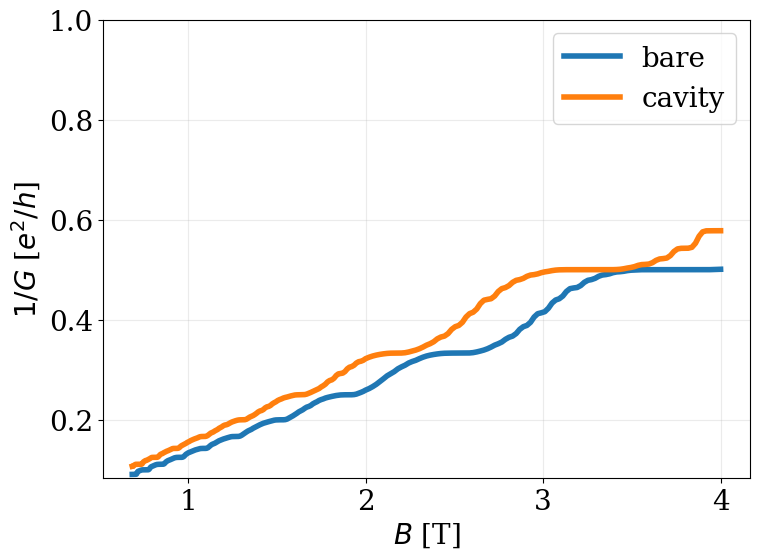

In [10]:

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(B_0, 1/G_0_smooth, lw=4, label="bare")
ax.plot(B_1, 1/G_1_smooth, lw=4, label="cavity")
#plt.plot(B_0,1.84e-3 * 2*np.pi*25.5**2 / B_0,label=r"$\propto 1/B$ reference",)

ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$1/G$ [$e^2/h$]")

#ax.set_yticks(np.arange(1/12,1,1) )
ax.set_ylim(1/12,1)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

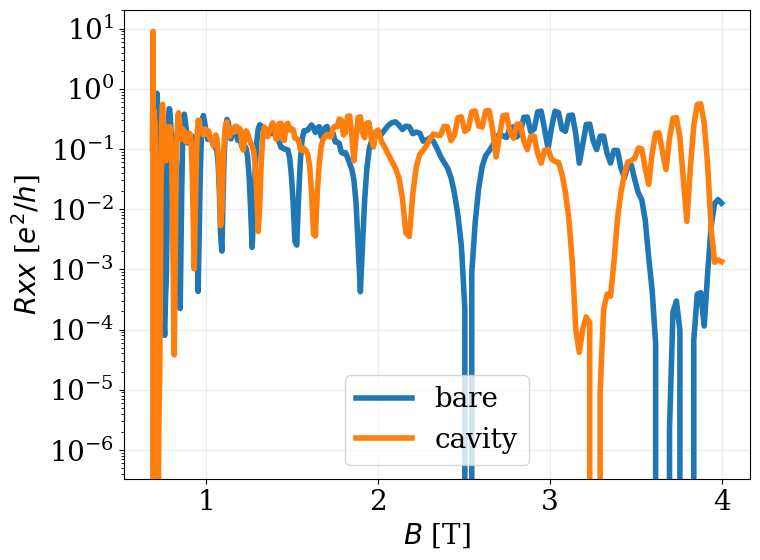

In [11]:

fig, ax = plt.subplots(figsize=(8, 6))

Rxx_0 = np.gradient(1/G_0_smooth, B_0)
Rxx_1 = np.gradient(1/G_1_smooth, B_1)

ax.plot(B_0, Rxx_0, lw=4, label="bare")
ax.plot(B_1, Rxx_1, lw=4, label="cavity")
#plt.plot(B_0,1.84e-3 * 2*np.pi*25.5**2 / B_0,label=r"$\propto 1/B$ reference",)

ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$Rxx$ [$e^2/h$]")
ax.set_yscale('log')
#ax.set_yticks(np.arange(1/12,1,1) )
#ax.set_ylim(1/12,1)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

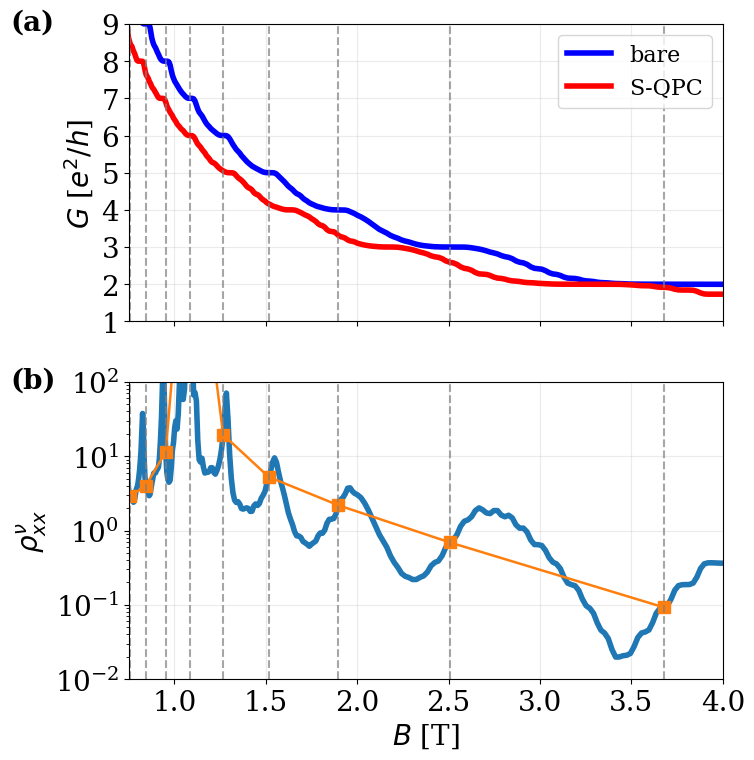

In [53]:
# ============================================================
# Combined 2-panel figure
# (a) Conductance comparison
# (b) rho_xx^nu
# ============================================================

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 8),
    sharex=True,
)


# ============================================================
# (a) Conductance
# ============================================================

ax1.plot(
    B_0, G_0_smooth,
    lw=4,
    color='blue',
    label="bare"
)

ax1.plot(
    B_1, G_1_smooth,
    lw=4,
    color='red',
    label="S-QPC"
)

#ax1.set_xlabel(r"$B$ [T]")
ax1.tick_params(axis="x", which="both", labelbottom=False)

ax1.set_ylabel(r"$G$ [$e^2/h$]")

ax1.set_yticks(np.arange(0, 12, 1))
ax1.set_ylim(1, 9)
ax1.set_xlim(.75,4)
ax1.grid(alpha=0.25)
ax1.legend(fontsize=16)

# Vertical lines at the bare-curve plateau positions
for Bp in B[plateau_idx]:
    ax1.axvline(
        Bp,
        color="0.5",
        ls="--",
        lw=1.5,
        alpha=0.7
    )


# ============================================================
# (b) rho_xx^nu
# ============================================================

ax2.plot(
    B,
    abs(rhoxxnu),
    ms=4,
    lw=4
)

ax2.plot(
    B[plateau_idx],
    abs(rhoxxnu[plateau_idx]),
    marker="s",
    ms=8,
    lw=1.8
)

ax2.axhline(
    0,
    color="0.5",
    ls="--",
    lw=1
)

ax2.set_xlabel(r"$B$ [T]")
ax2.set_ylabel(r"$\rho_{xx}^{\nu}$")

ax2.set_yscale("log")
ax2.set_ylim(1e-2, 1e2)
ax2.set_xlim(.75,4)

ax2.grid(alpha=0.25)

# Vertical lines at the bare-curve plateau positions
for Bp in B[plateau_idx]:
    ax2.axvline(
        Bp,
        color="0.5",
        ls="--",
        lw=1.5,
        alpha=0.7
    )

# Panel labels outside the axes, upper-left corner
ax1.text(
    -0.2, 1.05, "(a)",
    transform=ax1.transAxes,
    ha="left",
    va="top",
    fontsize=20,
    fontweight="bold"
)

ax2.text(
    -0.2, 1.05, "(b)",
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=20,
    fontweight="bold"
)

#fig.subplots_adjust(hspace=0.15)
# ------------------------------------------------------------
# Layout and save
# ------------------------------------------------------------
fig.tight_layout()

plt.savefig(
    "G_rhoxxnu_combined.pdf",
    bbox_inches="tight"
)

plt.show()